## BaseLine Classification


### Imports and Dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [6]:
from mnist1d.data import get_dataset_args, make_dataset
from common.models import LinearBase, MLPBase, ConvBase, GRUBase
from common.train import get_model_args, train_model

In [7]:
dataset = make_dataset(get_dataset_args())
print(dataset['x'].shape, dataset['y'].shape)

(4000, 40) (4000,)


### Hyperparameters and model builder

In [8]:
args = get_model_args()
args.total_steps = 3000 # default is 8000;
args.eval_every = 250
args.print_every = 3000

In [9]:
model_builder = {
    "Logistic" : lambda: LinearBase(args.input_size, args.output_size),
    "MLP"      : lambda: MLPBase(args.input_size, args.output_size),
    "CNN"      : lambda: ConvBase(args.output_size),
    "GRU"      : lambda: GRUBase(1, args.output_size, bidirectional=True), # Bidirectional = True matches paper repo
}

### Unshuffled

In [10]:
results = {}
for name, build in model_builder.items():
    torch.manual_seed(0)
    r = train_model(dataset, build(), args)
    results[name] = r["test_acc"][-1]
    print(f"{name:>10s}: {r['test_acc'][-1]:.1f}% test accuracy")

step 3000, dt 0.32s, train_loss 1.533e+00, test_loss 1.669e+00, train_acc 37.0, test_acc 31.7
  Logistic: 31.7% test accuracy
step 3000, dt 0.74s, train_loss 7.125e-03, test_loss 3.471e+00, train_acc 99.0, test_acc 64.2
       MLP: 64.2% test accuracy
step 3000, dt 16.64s, train_loss 7.762e-02, test_loss 3.696e-01, train_acc 99.4, test_acc 93.8
       CNN: 93.8% test accuracy
step 3000, dt 12.81s, train_loss 4.220e-02, test_loss 3.754e-01, train_acc 97.3, test_acc 90.4
       GRU: 90.4% test accuracy


### Shuffled

In [12]:
shuffled_args = get_dataset_args()
shuffled_args.shuffle_seq = True
shuffled_dataset = make_dataset(shuffled_args)

In [13]:
shuffled_results = {}
for name, build in model_builder.items():
    torch.manual_seed(0)
    r = train_model(shuffled_dataset, build(), args)
    shuffled_results[name] = r["test_acc"][-1]
    print(f"{name:>10s}: {r['test_acc'][-1]:.1f}% test accuracy (shuffled)")

step 3000, dt 0.31s, train_loss 1.533e+00, test_loss 1.670e+00, train_acc 37.1, test_acc 31.4
  Logistic: 31.4% test accuracy (shuffled)
step 3000, dt 0.72s, train_loss 9.067e-04, test_loss 3.178e+00, train_acc 100.0, test_acc 65.4
       MLP: 65.4% test accuracy (shuffled)
step 3000, dt 16.60s, train_loss 1.823e-01, test_loss 2.572e+00, train_acc 91.9, test_acc 56.6
       CNN: 56.6% test accuracy (shuffled)
step 3000, dt 12.78s, train_loss 4.859e-01, test_loss 1.515e+00, train_acc 80.9, test_acc 55.3
       GRU: 55.3% test accuracy (shuffled)


## Figures

     model   unshuffled   shuffled     drop
  Logistic        31.7%      31.4%     0.3pp
       MLP        64.2%      65.4%    -1.2pp
       CNN        93.8%      56.6%    37.2pp
       GRU        90.4%      55.3%    35.1pp


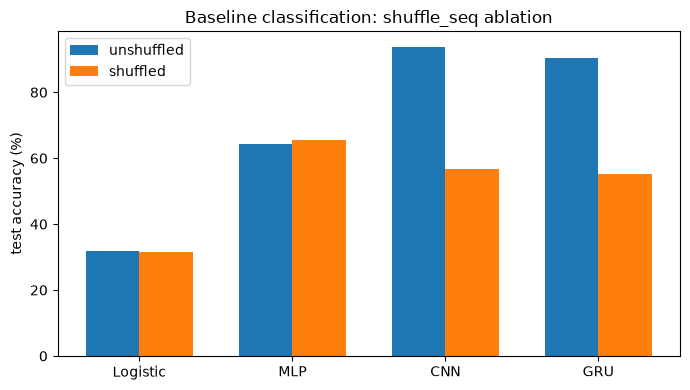

In [15]:
print(f"{'model':>10s} {'unshuffled':>12s} {'shuffled':>10s} {'drop':>8s}")
for name in model_builder:
    drop = results[name] - shuffled_results[name]
    print(f"{name:>10s} {results[name]:>11.1f}% {shuffled_results[name]:>9.1f}% {drop:>7.1f}pp")

names = list(model_builder.keys())
x = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, [results[n] for n in names], width, label="unshuffled")
ax.bar(x + width/2, [shuffled_results[n] for n in names], width, label="shuffled")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("test accuracy (%)")
ax.set_title("Baseline classification: shuffle_seq ablation")
ax.legend()
plt.tight_layout()
plt.show()
